# Course Project: Analysis of fuel prices

### Statement of AI usage

AI (ChatGPT/Claude) has been used for troubleshooting code (to solve errors). AI has also been used to help with improving visualisations of the data.

### NOTEBOOK USAGE

Using this notebook requires the following things: installed kaggle, possibly linearmodels. Do this via '!pip install kaggle' or '!pip install linearmodels' within this notebook.

The raw data can be found in the repository at 'Project/data/global_fuel_prices_2020_2026.csv'. 

To be able to use the Kaggle API, the user needs to create an account at Kaggle, and follow the instructions provided by Kaggle to setup the API token. These can for example be found when requesting an API token via your Kaggle profile. 

**Description**

The aim of this project is to determine if brent crude barrel prices are reflected in fuel prices. The analysis also checks if subsidies have a significant impact on fuel prices. The analysis is done for petrol and diesel, for the period 2020-2026. The data consists of 27,468 observations in weekly format from 84 different countries. 

**Methodology**

With the use of panel data regressions. As the data contains variables that don't change over time ('subsidy_level' and 'income_level', a fixed effects model cannot be used and thus a random effects model will be used. Since the data is in weekly format, year dummies will be used instead to control for shocks/trends. 

The model is the following:

Dependent variable: petrol_usd_liter, diesel_usd_liter (ran separately)

Independent variables: brent_crude_usd, subsidy_level

Control variables: tax_percentage, income_level

Time effect: Year dummy





### Project Pipeline

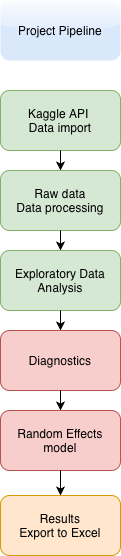

## Data import and exploration 

In [1]:
import os
os.chdir("/Users/felix/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/Python4BusinessInt")
#set your working directory here

In [2]:
import kaggle #using the Kaggle api to download the datafile. 
#check the settings of your Kaggle profile for instructions on how to setup the API token
kaggle.api.dataset_download_files(
    "belbino/global-fuel-prices-20202026",
    path="./Project/data",
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/belbino/global-fuel-prices-20202026


In [3]:
import pandas as pd
df=pd.read_csv("./Project/data/global_fuel_prices_2020_2026.csv")

In [4]:
df.describe().round(2)

,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
count,27468.00,27468.00,27468.00,27468.00,27468.00
mean,2.28,2.13,1.71,106.69,26.77
std,1.54,1.47,1.16,18.97,17.20
min,0.01,0.01,0.01,47.97,0.00
25%,0.93,0.86,0.70,101.14,13.50
50%,2.12,1.95,1.59,112.27,23.40
75%,3.46,3.23,2.59,119.41,38.90
max,6.78,6.24,5.10,130.00,65.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  object 
 1   country           27468 non-null  object 
 2   region            27468 non-null  object 
 3   income_level      27468 non-null  object 
 4   subsidy_level     27468 non-null  object 
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), object(5)
memory usage: 2.1+ MB


In [6]:
df.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


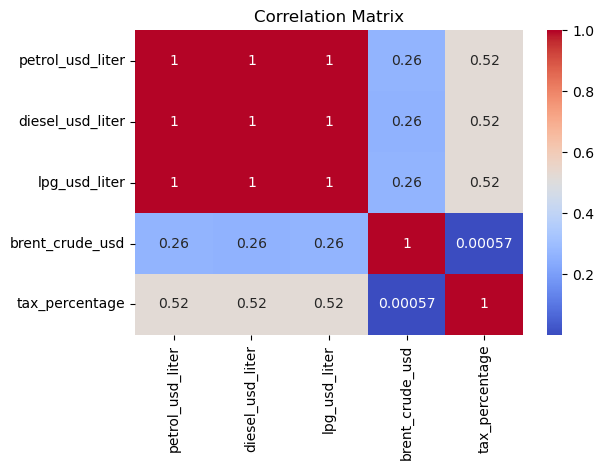

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df[["petrol_usd_liter", "diesel_usd_liter", "lpg_usd_liter", "brent_crude_usd", "tax_percentage"]]

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

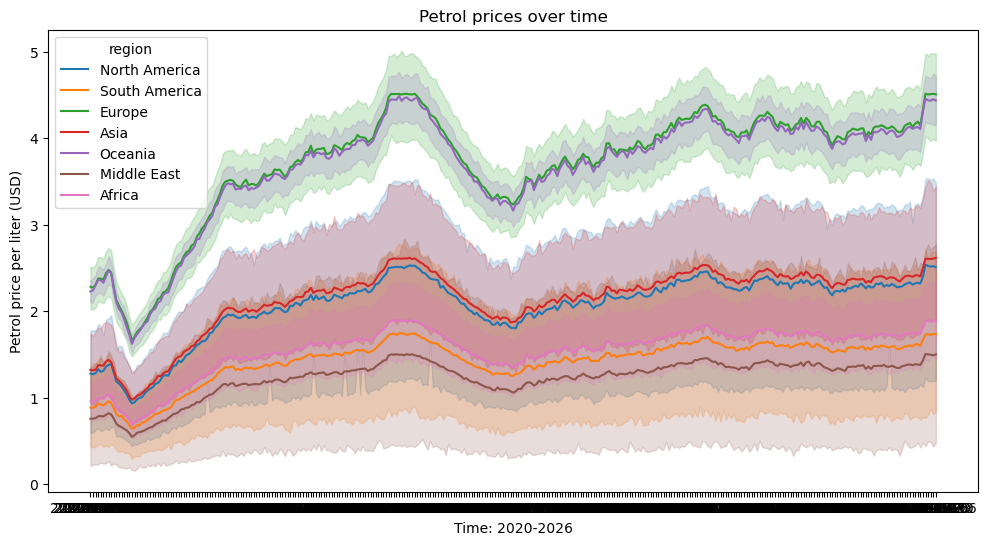

In [8]:
plt.subplots(figsize=(12, 6))
sns.lineplot(data= df, x="date", y="petrol_usd_liter", hue="region")
plt.title("Petrol prices over time")
plt.xlabel("Time: 2020-2026")
plt.ylabel("Petrol price per liter (USD)")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

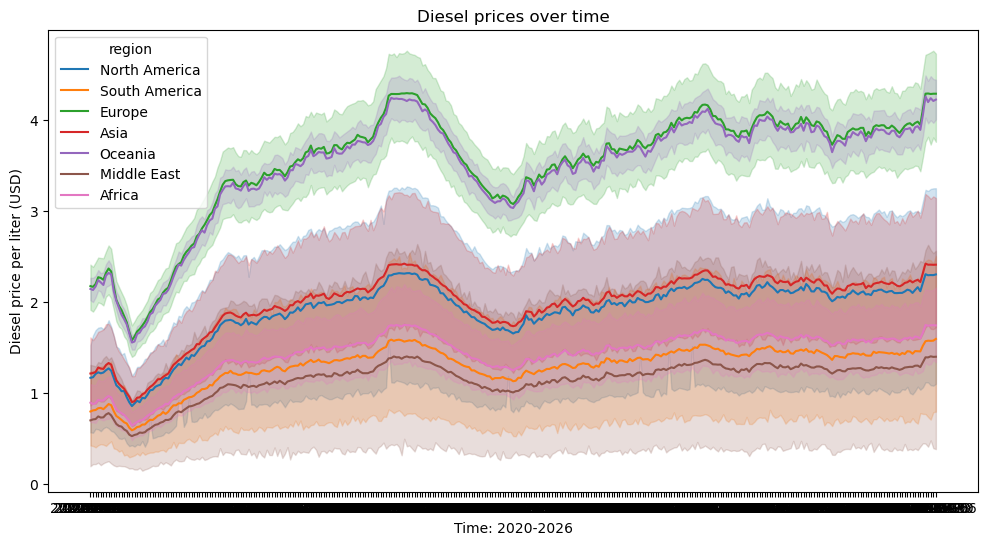

In [9]:
plt.subplots(figsize=(12, 6))
sns.lineplot(data= df, x="date", y="diesel_usd_liter", hue ="region")
plt.title("Diesel prices over time")
plt.xlabel("Time: 2020-2026")
plt.ylabel("Diesel price per liter (USD)")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

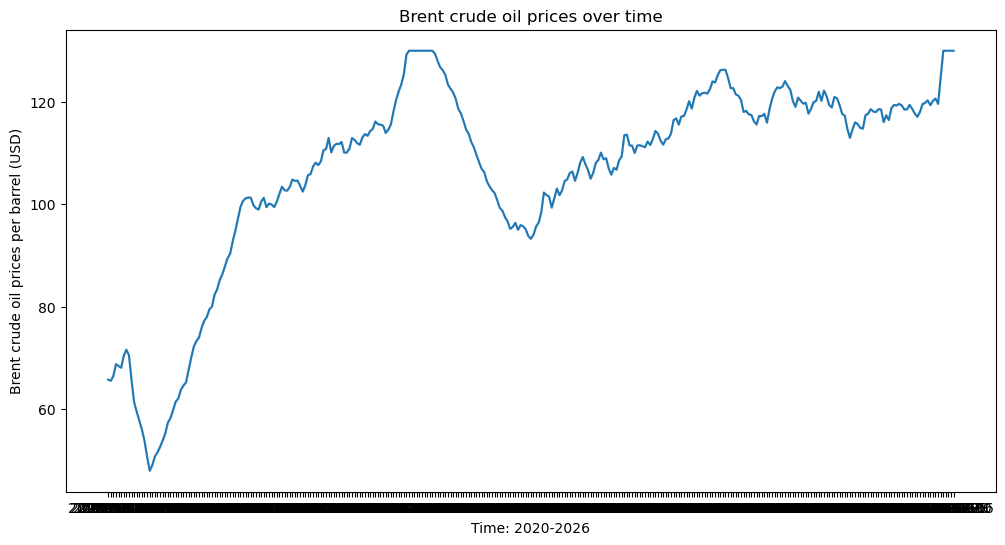

In [10]:
plt.subplots(figsize=(12, 6))
sns.lineplot(data= df, x="date", y="brent_crude_usd")
plt.title("Brent crude oil prices over time")
plt.xlabel("Time: 2020-2026")
plt.ylabel("Brent crude oil prices per barrel (USD)")
plt.show

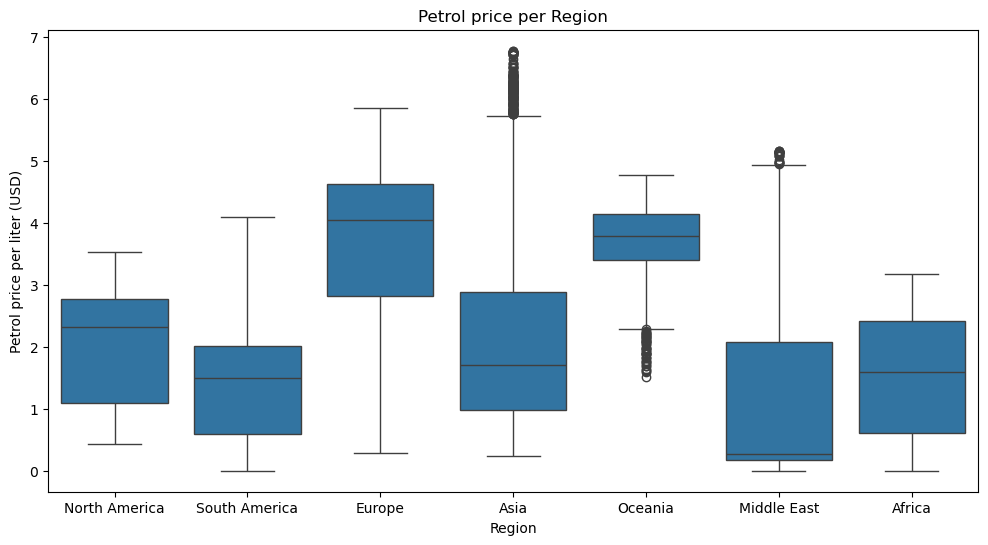

In [11]:
plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x="region", y="petrol_usd_liter")
plt.title("Petrol price per Region")
plt.xlabel("Region")
plt.ylabel("Petrol price per liter (USD)")
plt.show()

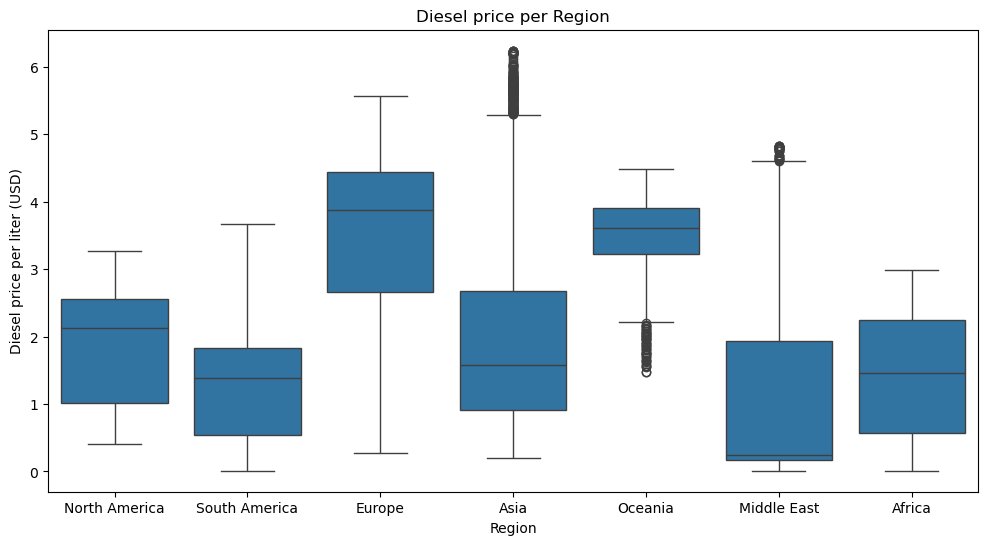

In [12]:
plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x="region", y="diesel_usd_liter")
plt.title("Diesel price per Region")
plt.xlabel("Region")
plt.ylabel("Diesel price per liter (USD)")
plt.show()

### Visual analysis of prices

As can be observed from the above graphs, the prices of both petrol and diesel seem to be very close to each other, and with similar movements. This can also be checked from the correlation matrix (corr = 1). In addition, the price movements of brent crude oil seem to visually move in a similar pattern as the fuel prices. Due to this, one could expect that fuel prices are dependant on brent crude oil prices. The correlation between the two lies at 0,52. 

## Data processing

As could be seen in the previous part, columns 'income_level' and 'subisdy_level' need to be transformed into dummies, as they are categorical. In addition, to be able to include time effects, I have decided to include year dummies. If weekly dates were to be used, there's a possibility that the time variable would "soak up" all of the variations. 

I have decided to not handle outliers, as tuning down the data would create false scenarios, as shocks are important to include in this context.

In [13]:
print(df["subsidy_level"].unique())
print(df["income_level"].unique())

['Low' 'High' 'Medium' 'Very High']
['High' 'Middle' 'Low']


In [14]:
df = pd.get_dummies(df, columns=["subsidy_level", "income_level"], drop_first=True)
df.head()

,date,country,region,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,subsidy_level_Low,subsidy_level_Medium,subsidy_level_Very High,income_level_Low,income_level_Middle
0,2020-01-06,United States,North America,1.465,1.289,1.093,65.75,59.6,True,False,False,False,False
1,2020-01-13,United States,North America,1.435,1.319,1.077,65.54,27.6,True,False,False,False,False
2,2020-01-20,United States,North America,1.446,1.329,1.080,66.51,62.3,True,False,False,False,False
3,2020-01-27,United States,North America,1.488,1.359,1.125,68.79,44.8,True,False,False,False,False
4,2020-02-03,United States,North America,1.457,1.341,1.111,68.44,51.4,True,False,False,False,False


In [15]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
year_dummies = pd.get_dummies(df['year'], prefix='year', drop_first=True)
df = pd.concat([df, year_dummies], axis=1)
df.head()

,date,country,region,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,subsidy_level_Low,subsidy_level_Medium,subsidy_level_Very High,income_level_Low,income_level_Middle,year,year_2021,year_2022,year_2023,year_2024,year_2025,year_2026
0,2020-01-06,United States,North America,1.465,1.289,1.093,65.75,59.6,True,False,False,False,False,2020,False,False,False,False,False,False
1,2020-01-13,United States,North America,1.435,1.319,1.077,65.54,27.6,True,False,False,False,False,2020,False,False,False,False,False,False
2,2020-01-20,United States,North America,1.446,1.329,1.080,66.51,62.3,True,False,False,False,False,2020,False,False,False,False,False,False
3,2020-01-27,United States,North America,1.488,1.359,1.125,68.79,44.8,True,False,False,False,False,2020,False,False,False,False,False,False
4,2020-02-03,United States,North America,1.457,1.341,1.111,68.44,51.4,True,False,False,False,False,2020,False,False,False,False,False,False


In [16]:
df = df.set_index(["country", "date"]) #setting index for panel data

In [17]:
#Performing a basic PooledOLS
from linearmodels import PooledOLS
import statsmodels.api as sm
indep = sm.tools.tools.add_constant(df[['brent_crude_usd', 'tax_percentage', 'subsidy_level_Low', 'subsidy_level_Medium', 'subsidy_level_Very High', 'income_level_Low', 'income_level_Middle','year_2021', 'year_2022','year_2023', 'year_2024', 'year_2025', 'year_2026']])
dep = df['petrol_usd_liter']
mod = PooledOLS(dep, indep)
pooledOLS_res = mod.fit(cov_type='clustered', cluster_entity=True)
residuals_pooled_OLS = pooledOLS_res.resids
print(pooledOLS_res)


                          PooledOLS Estimation Summary                          
Dep. Variable:       petrol_usd_liter   R-squared:                        0.8804
Estimator:                  PooledOLS   R-squared (Between):              0.8992
No. Observations:               27468   R-squared (Within):               0.7078
Date:                Sun, May 10 2026   R-squared (Overall):              0.8804
Time:                        14:03:41   Log-likelihood                -2.168e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.554e+04
Entities:                          84   P-value                           0.0000
Avg Obs:                       327.00   Distribution:                F(13,27454)
Min Obs:                       327.00                                           
Max Obs:                       327.00   F-statistic (robust):             64.086
                            

### Diagnostics

Time to check for heteroskedasticity and autocorrelation. This will be tested via a Breusch-Pagan and Durbin-Watson tests. As can be seen from the results below, both are present. This will require HAC standard errors to correct for these violations.

In [18]:
import statsmodels.stats.diagnostic as diag

bp_test = diag.het_breuschpagan(residuals_pooled_OLS, indep)
print(f"LM Statistic: {bp_test[0]:.4f}")
print(f"p-value: {bp_test[1]:.4f}")

LM Statistic: 5375.1603
p-value: 0.0000


In [19]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals_pooled_OLS)
print(f"Durbin-Watson: {dw:.4f}")

Durbin-Watson: 0.0135


**Comment:** As the DW test is so close to zero, indicating strong positive autocorrelation, it gives reason to believe that a RE/FE model would be a better fit. However, as 'income_level' and 'subsidy_level' don't change over time, a Fixed Effects model cannot be used. Hence I'll only proceed with the Random Effects model. 

In [20]:
from linearmodels import RandomEffects
dep = df['petrol_usd_liter']
# RE (Random Effects) model
model_re = RandomEffects(dep, indep) 
RE_results_petrol = model_re.fit(cov_type="kernel") 
display(RE_results_petrol)

Dep. Variable:,petrol_usd_liter,R-squared:,0.7092
Estimator:,RandomEffects,R-squared (Between):,0.8992
No. Observations:,27468,R-squared (Within):,0.7078
Date:,"Sun, May 10 2026",R-squared (Overall):,0.8804
Time:,14:03:42,Log-likelihood,-2100.6
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,5150.4
Entities:,84,P-value,0.0000
Avg Obs:,327.00,Distribution:,"F(13,27454)"
Min Obs:,327.00,,
Max Obs:,327.00,F-statistic (robust):,9.425e+05


In [21]:
dep = df['diesel_usd_liter']

model_re = RandomEffects(dep, indep) 
RE_results_diesel = model_re.fit(cov_type="kernel") 
display(RE_results_diesel)

Dep. Variable:,diesel_usd_liter,R-squared:,0.7006
Estimator:,RandomEffects,R-squared (Between):,0.8945
No. Observations:,27468,R-squared (Within):,0.6992
Date:,"Sun, May 10 2026",R-squared (Overall):,0.8758
Time:,14:03:42,Log-likelihood,-792.94
Cov. Estimator:,Driscoll-Kraay,,
,,F-statistic:,4942.2
Entities:,84,P-value,0.0000
Avg Obs:,327.00,Distribution:,"F(13,27454)"
Min Obs:,327.00,,
Max Obs:,327.00,F-statistic (robust):,1.956e+06


In [22]:
#Incase the export below doesn't work, install the pandas excel dependencies with the line below
#!pip install "pandas[excel]"

In [23]:
df = pd.concat((RE_results_petrol.params, RE_results_petrol.pvalues), axis=1)

os.makedirs("./Project/results", exist_ok=True)#creating the subfolder

df.rename(columns={0: 'beta', 1: 'p_val'}).to_excel('./Project/Results/output_petrol.xlsx', sheet_name= 'petrol_res')

In [24]:
df = pd.concat((RE_results_diesel.params, RE_results_diesel.pvalues), axis=1)
df.rename(columns={0: 'beta', 1: 'p_val'}).to_excel('./Project/Results/output_diesel.xlsx', sheet_name= 'diesel_res')

## Analysing the results

As expected from the visual analysis, brent crude oil is highly significant with a p-value close to 0, for both petrol and diesel. The coefficient estimate is positive, indicating that an increase in brent crude oil prices also increases the price of the fuel. Both models seem to be working very well, with an overall R-squared of 0,87-0,88, with petrol having the higher one. Interestingly, not one of the dummies is significant. However they needed to be controlled for. Some 'income_level' and 'subsidy_level' dummies have a negative coefficient estimate, which would indicate that under those circumstances where they are present, fuel prices are lower. However they are not significant, so no conclusions can be drawn from that observation. 